# Tech Challenge - Fase 1: Tratamento e Análise Exploratória (EDA)
**Objetivo:** Preparar os dados de e-commerce para a modelagem preditiva, garantindo a integridade estatística, a ausência de *Data Leakage* e a compreensão profunda das correlações operacionais que impactam a satisfação do cliente.


In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
# Configurações visuais e de sistema
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
%matplotlib inline

# Carregando a base original
df = pd.read_csv('desafio_nps_fase_1.csv')
print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas.")

Dataset carregado: 2500 registros e 19 colunas.


In [3]:
# Visão geral da estrutura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [4]:
df.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


## 1. Tratamento e Prevenção de Fuga de Dados (Data Leakage)
Nesta etapa, removemos variáveis que são coletadas **após** a pesquisa de NPS ou que indicam o resultado da pesquisa de forma direta. O objetivo é prever a nota com base apenas em indicadores operacionais que a empresa já possui antes do cliente responder à pesquisa.

* **complaints_count:** Removida por ser um evento posterior.
* **csat_internal_score:** Removida para evitar redundância direta com o NPS.
* **nps_class:** Removida para focarmos na **Regressão** da nota (0-10), conforme sugestão da banca.

In [5]:
# 1. Lista de colunas para exclusão (Leakage e Identificadores)
drop_cols = ['order_id', 'customer_id', 'complaints_count', 'csat_internal_score']

# Removendo as colunas indesejadas
df_clean = df.drop(columns=drop_cols)

# 2. Transformando texto em números (One-Hot Encoding)
# Transforma 'customer_region' em colunas (ex: customer_region_Sul = 1 ou 0)
df_clean = pd.get_dummies(df_clean, columns=['customer_region'], drop_first=True)

# 3. Verificação e remoção de valores nulos
if df_clean.isnull().sum().sum() > 0:
    df_clean = df_clean.dropna()
    print("Valores nulos removidos.")

print(f"Dataset limpo e encodado: {df_clean.shape[0]} linhas e {df_clean.shape[1]} colunas.")
df_clean.head()

Dataset limpo e encodado: 2500 linhas e 18 colunas.


,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,True,False,False,False
1,20,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,False,False,False,True
2,46,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,True,False,False,False
3,52,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,False,False,False,False
4,56,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,False,True,False,False


## 2. Análise de Multicolinearidade (Matriz de Correlação)
Abaixo, apresentamos a matriz de correlação completa. Este gráfico é vital para identificar se duas variáveis operacionais explicam a mesma coisa (Multicolinearidade) e para visualizar a força do impacto de cada fator na nota de NPS.

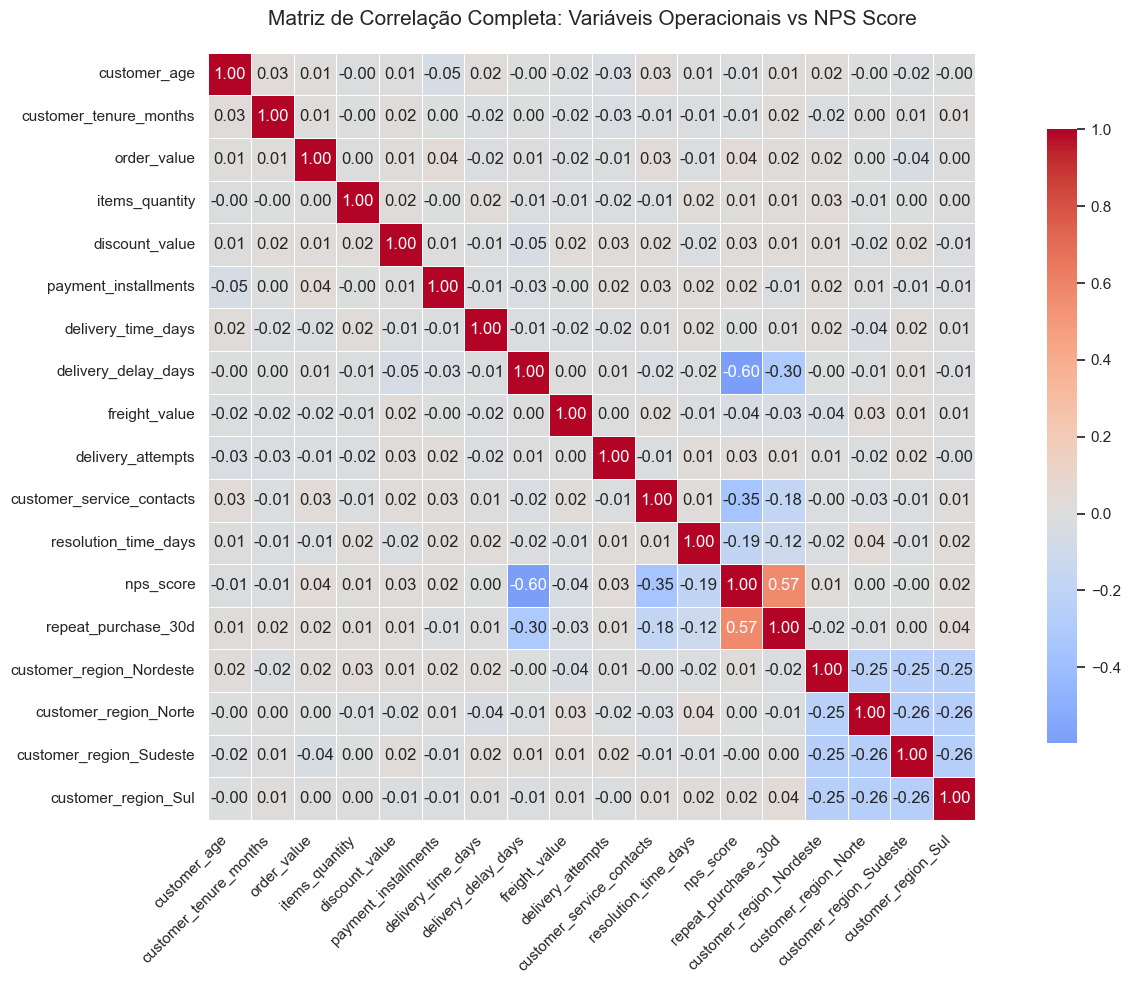

In [6]:
plt.figure(figsize=(15, 10))

# Calculando a correlação de todas as variáveis numéricas
corr_matrix = df_clean.corr()

# Criando o Heatmap completo (sem máscara)
sns.heatmap(corr_matrix, 
            annot=True,          # Exibe os valores em cada célula
            fmt=".2f",           # Formatação com 2 casas decimais
            cmap='coolwarm',       # Paleta clássica
            center=0,            # Garante que o branco seja o zero (sem correlação)
            linewidths=0.5,      # Linhas finas separando as células
            square=True,         # Mantém as células em formato de quadrado
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação Completa: Variáveis Operacionais vs NPS Score', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Análise da Variável Alvo: nps_score
Como o modelo será de **Regressão**, precisamos entender a distribuição das notas. O problema identificado na classificação de 'Neutros' ocorre porque as notas 7 e 8 estão muito próximas das fronteiras de Detratores (6) e Promotores (9). A regressão tratará essa transição de forma contínua.

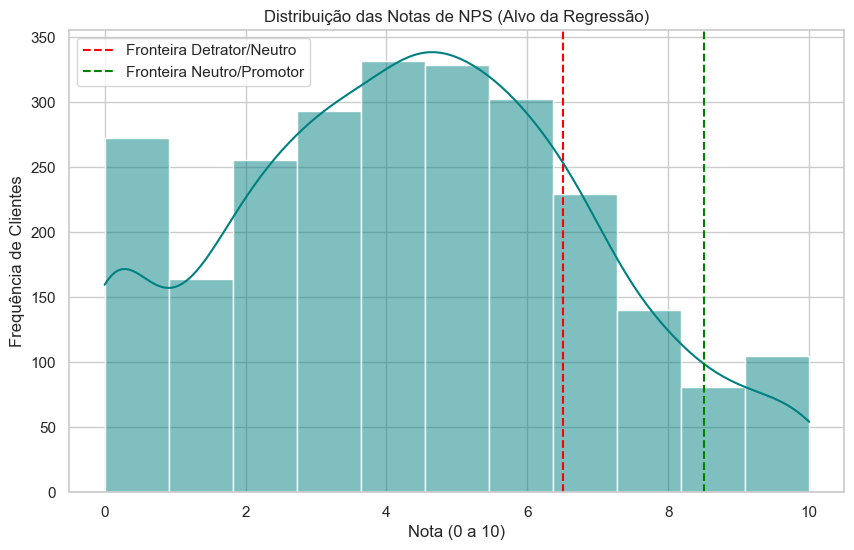

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['nps_score'], bins=11, kde=True, color='teal')
plt.title('Distribuição das Notas de NPS (Alvo da Regressão)')
plt.xlabel('Nota (0 a 10)')
plt.ylabel('Frequência de Clientes')
plt.axvline(6.5, color='red', linestyle='--', label='Fronteira Detrator/Neutro')
plt.axvline(8.5, color='green', linestyle='--', label='Fronteira Neutro/Promotor')
plt.legend()
plt.show()

## 4. Exportação para Modelagem
Com os dados limpos, as correlações mapeadas e a variável alvo definida como numérica, exportamos o dataset para o **Notebook 02**, onde aplicaremos o modelo de Regressão e o split de Treino/Teste.

In [8]:
df_clean.to_csv('dados_preparados_regressao.csv', index=False)
print("Dados exportados com sucesso. Pronto para a etapa de Modelagem Preditiva.")

Dados exportados com sucesso. Pronto para a etapa de Modelagem Preditiva.
